This code matches segmentation TIFF images with their corresponding tree crown shapefiles based on a common identifier extracted from their filenames. It then visualizes each pair by displaying the raster segmentation in the green channel and the tree crown polygons in blue (ground truth). This provides a quick visual check of the spatial alignment between model predictions and reference tree crowns.

Répertoire de travail actuel : /workspaces/GLO-7030_Projet-NRCAN-Lidar/TreeCountSegHeight/files_added_in_the_repo


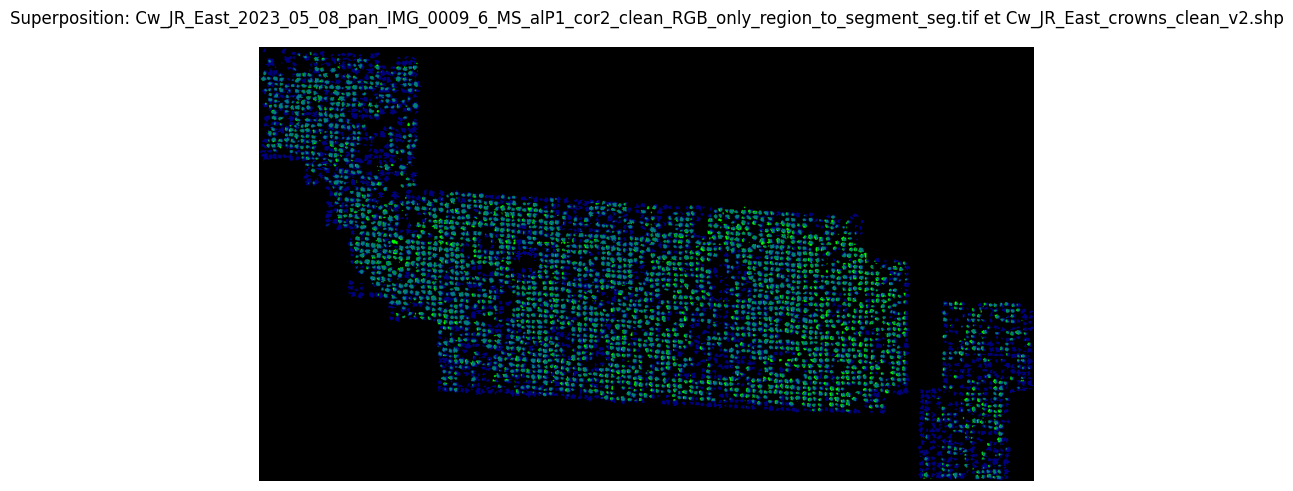

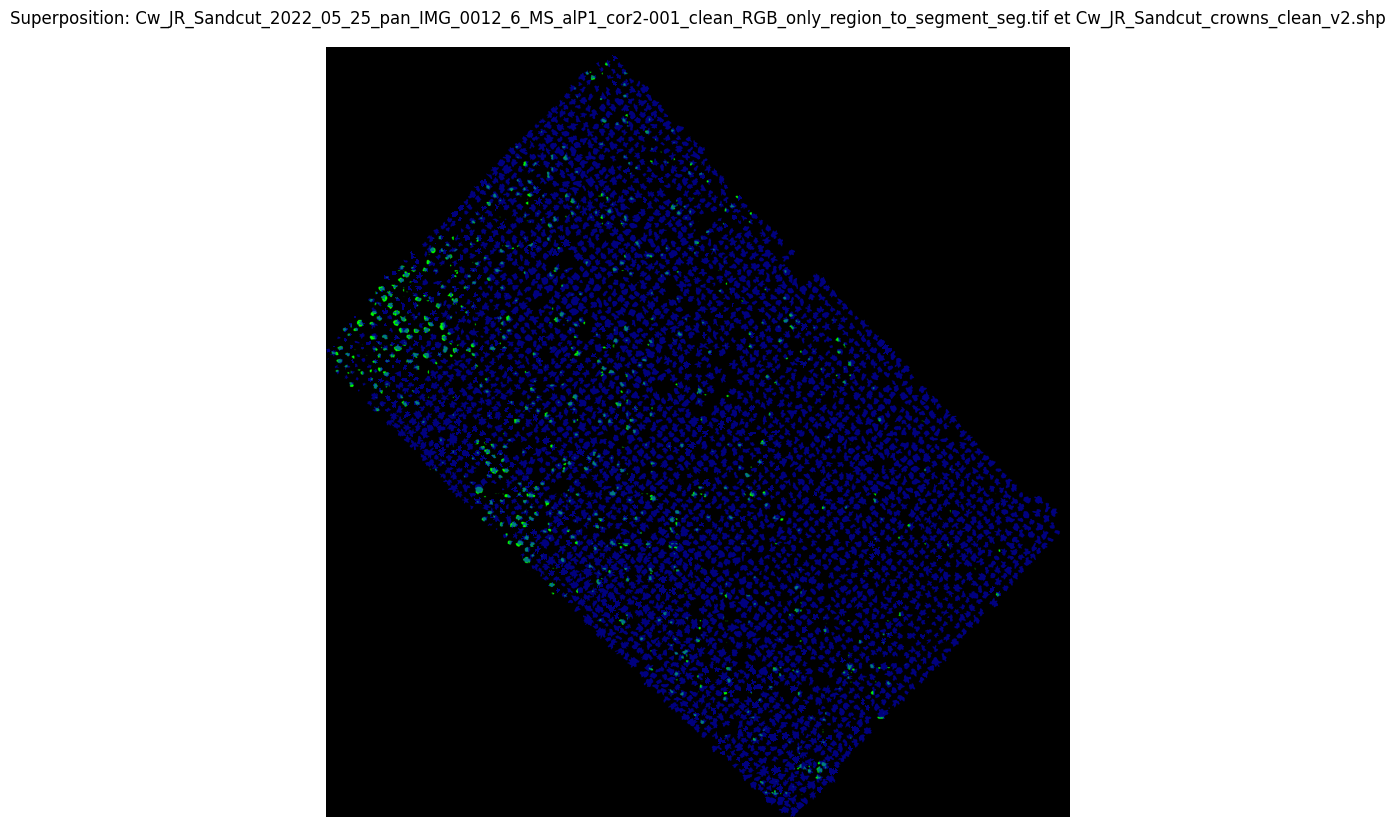

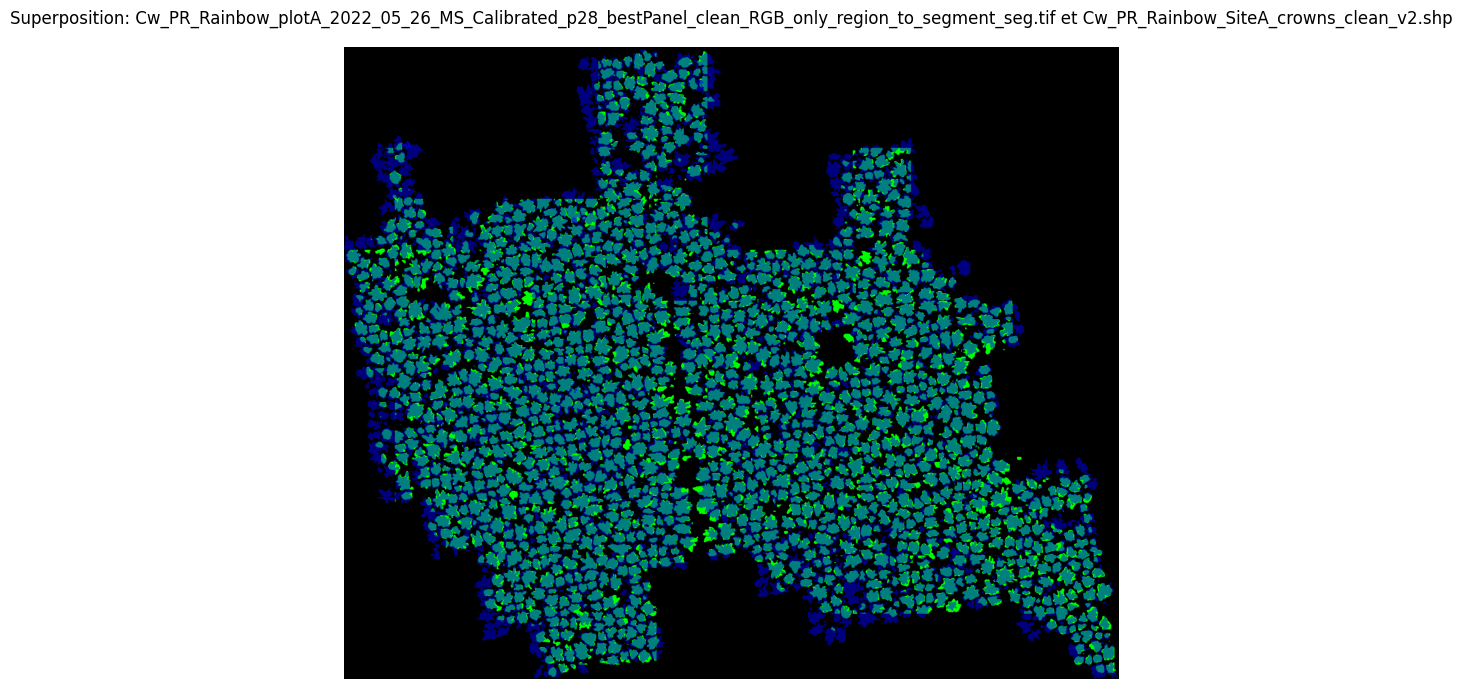

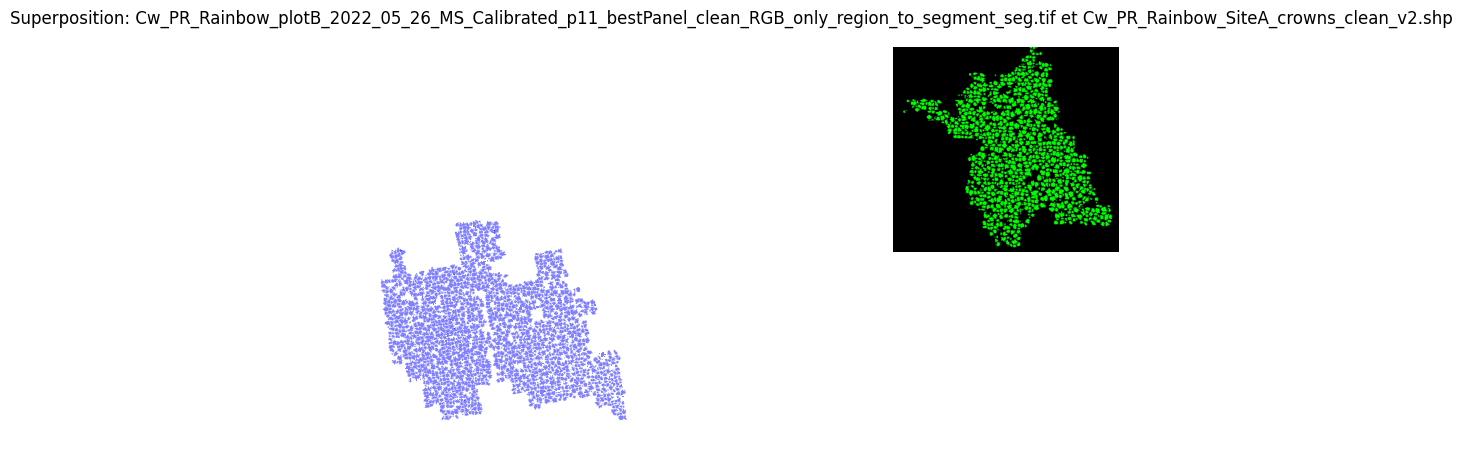

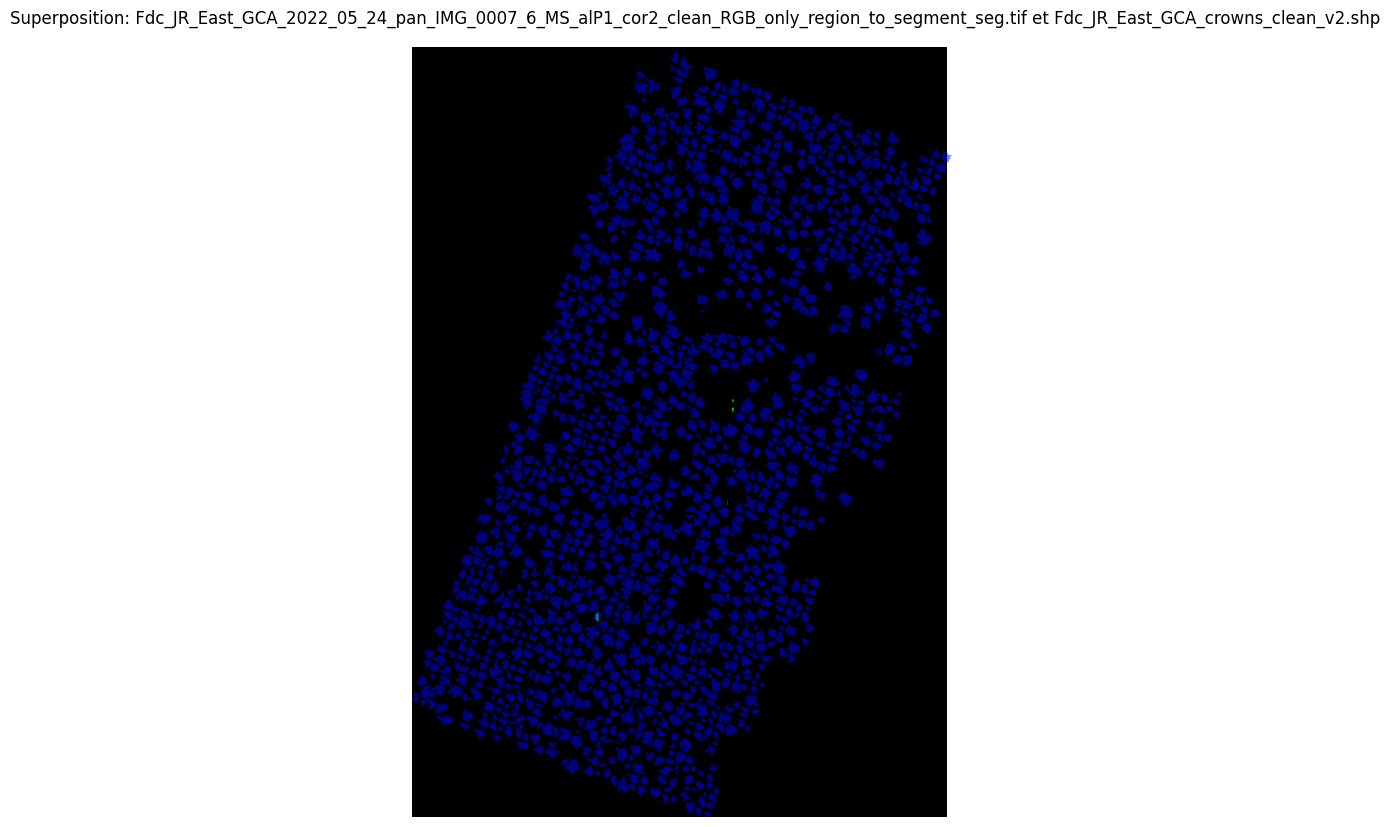

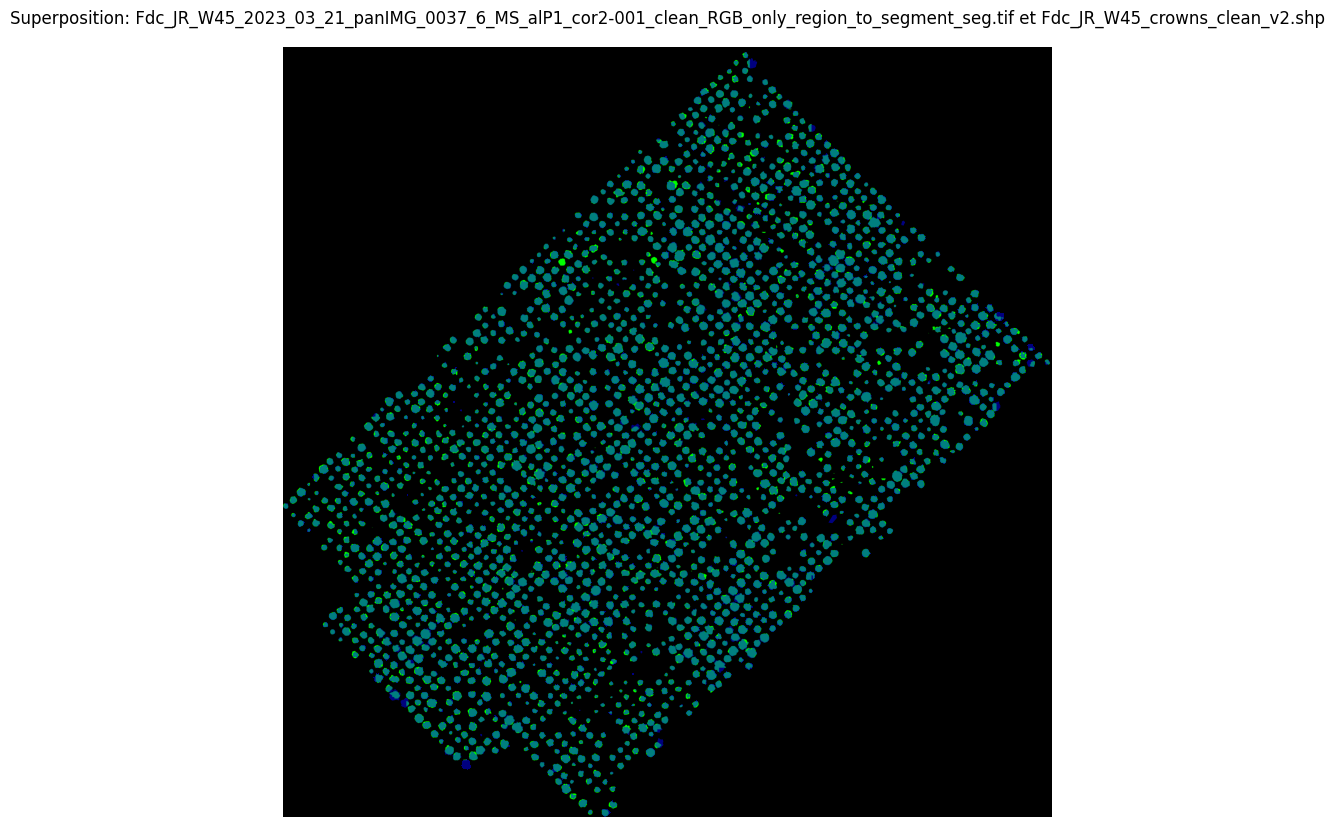

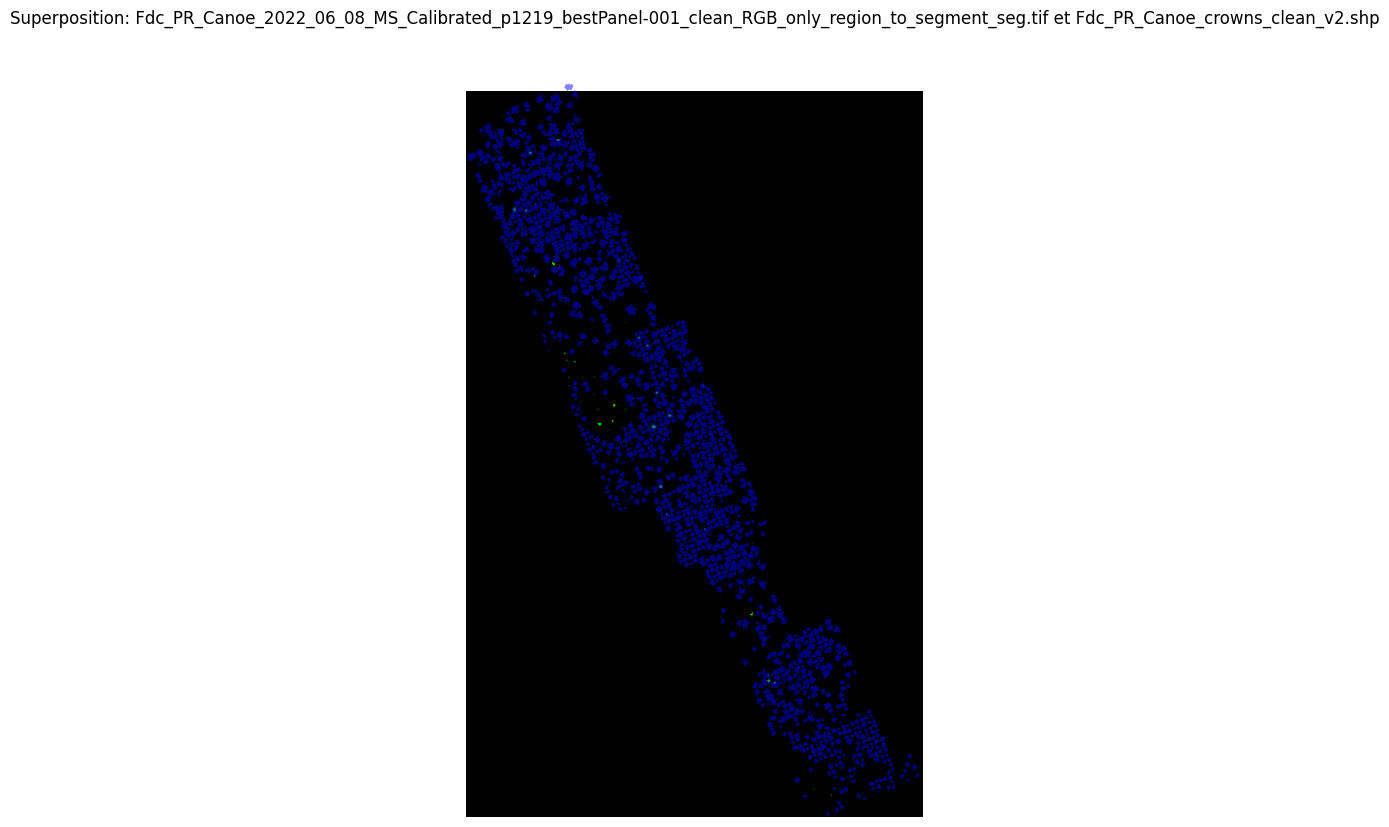

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import plotting_extent
import geopandas as gpd

print(f"Répertoire de travail actuel : {Path.cwd()}")

tiff_dir = Path("../../TreeCountSegHeight/files_added_in_the_repo/inference_plantation_RGB/all_sites/predictions_RGB_bw2")
shp_dir = Path("../../TreeCountSegHeight/files_added_in_the_repo/crowns")

def extract_identifier(filename):
    return "_".join(filename.stem.split("_")[:3])

tiff_files = list(tiff_dir.glob("*_seg.tif"))
shp_files = list(shp_dir.glob("*.shp"))

file_pairs = []
for tiff_file in tiff_files:
    tiff_id = extract_identifier(tiff_file)
    for shp_file in shp_files:
        shp_id = extract_identifier(shp_file)
        if tiff_id == shp_id:
            file_pairs.append((tiff_file, shp_file))
            break

for tiff_file, shp_file in file_pairs:
    with rasterio.open(tiff_file) as src:
        tiff_data = src.read(1)
        tiff_extent = plotting_extent(src)

    shp_data = gpd.read_file(shp_file)

    height, width = tiff_data.shape
    rgb_image = np.zeros((height, width, 3), dtype=np.uint8)

    # Ajouter le TIFF au canal vert
    rgb_image[:, :, 1] = (tiff_data / tiff_data.max() * 255).astype(np.uint8)

    # Ajouter le SHP au canal bleu
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(rgb_image, extent=tiff_extent, origin="upper")
    shp_data.plot(ax=ax, color="blue", alpha=0.5)

    plt.title(f"Superposition: {tiff_file.name} et {shp_file.name}")
    plt.axis("off")
    plt.show()